# Insurance Claim EDA

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading Dataset

In [2]:
df = pd.read_csv('insurance_data.csv')

In [3]:
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
df.shape

(1340, 11)

# Data Cleaning
### Missing Value Treatment:
The dataset contained 5 missing values in the age column and 3 missing values in the region column. The missing values in age were imputed using the mean (or median, if you choose that), while the missing values in region were imputed using the mode. Since the number of missing values was very small relative to the dataset size, this preprocessing step is not expected to significantly affect the exploratory data analysis.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['region'] = df['region'].fillna(df['region'].mode()[0])
df['age'] = df['age'].fillna(df['age'].mean())

# Labeling Columns 
- **Numerical** -> PatientID,age,bmi,bloodpressure,children,claim
- **Categorical** - >gender,diabetic,smoker,region
- **Mixed** -> NON

# **Univariate Analysis**
## @ Numerical columns

## 1. Age

**conclusions**
- Age is normally distributed
- There are no outliers
  

In [8]:
df['age'].describe()

count    1340.000000
mean       38.078652
std        11.082175
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

<Axes: ylabel='Density'>

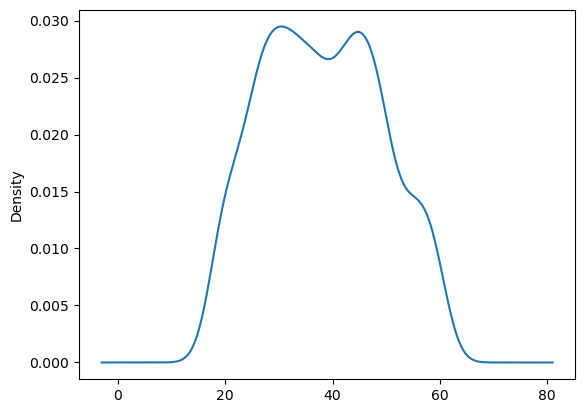

In [9]:
df['age'].plot(kind='kde')

<Axes: ylabel='Frequency'>

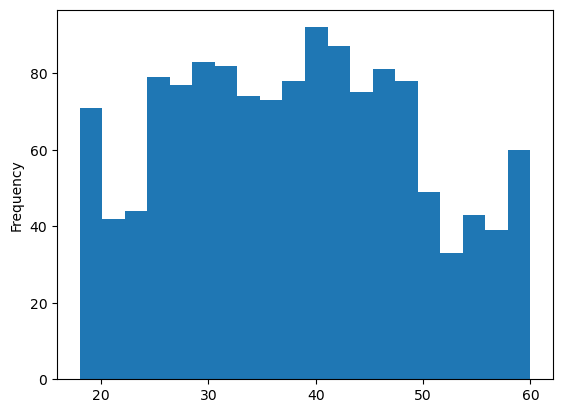

In [10]:
df['age'].plot(kind='hist',bins=20)

<Axes: >

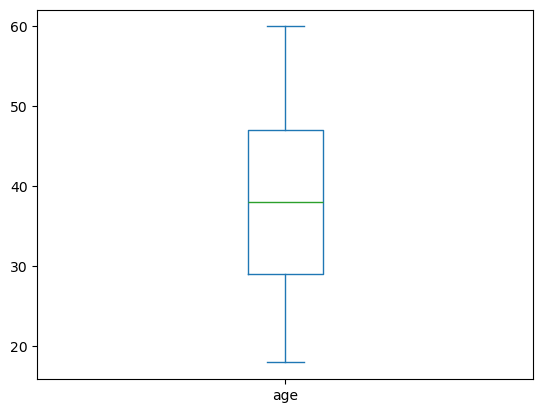

In [11]:
df['age'].plot(kind='box')

In [12]:
df['age'].skew()

np.float64(0.11382341584545372)

In [13]:
df['age'].isnull().sum()

np.int64(0)

## 2.Bmi
**conclusions**
- bmi is normally distributed
- There are several high- value outliers. 

In [14]:
df['bmi'].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

<Axes: ylabel='Density'>

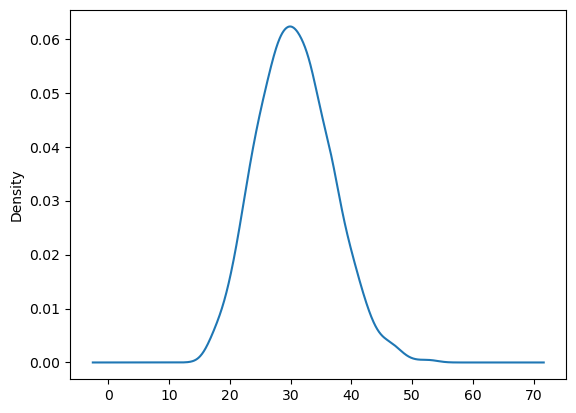

In [15]:
df['bmi'].plot(kind='kde')

In [16]:
df['bmi'].skew()

np.float64(0.28597245020808587)

<Axes: >

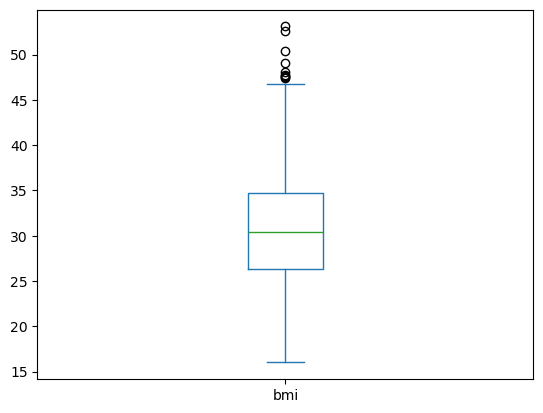

In [17]:
df['bmi'].plot(kind='box')

In [18]:
df[df['bmi'] > 50]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46
141,141,142,46.0,male,50.4,89,Yes,1,No,southeast,2438.06
1299,1299,1300,50.0,male,52.6,110,No,1,Yes,southeast,44501.40


<Axes: ylabel='Frequency'>

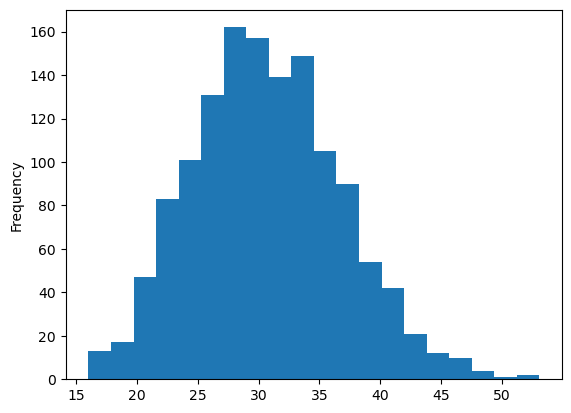

In [19]:
df['bmi'].plot(kind='hist',bins=20)

In [20]:
df['bmi'].isnull().sum()

np.int64(0)

## 3.Bloodpressure	
**conclusions**
- 'Bloodpressure' col is positively skewed
- There are several high-valued outliers. 

In [21]:
df['bloodpressure'].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

<Axes: ylabel='Frequency'>

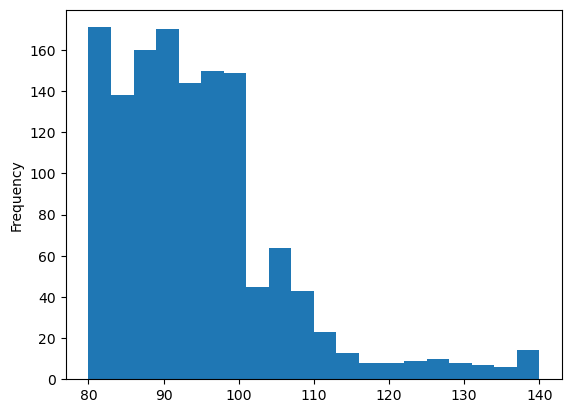

In [22]:
df['bloodpressure'].plot(kind='hist',bins=20)

In [23]:
df['bloodpressure'].skew()

np.float64(1.4835342102293079)

<Axes: ylabel='Density'>

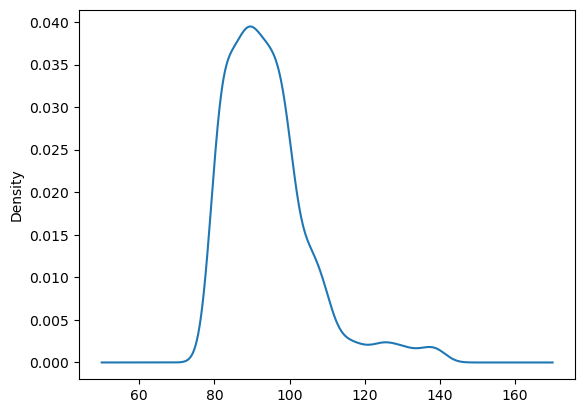

In [24]:
df['bloodpressure'].plot(kind='kde')

In [25]:
df['bloodpressure'].isnull().sum()

np.int64(0)

<Axes: >

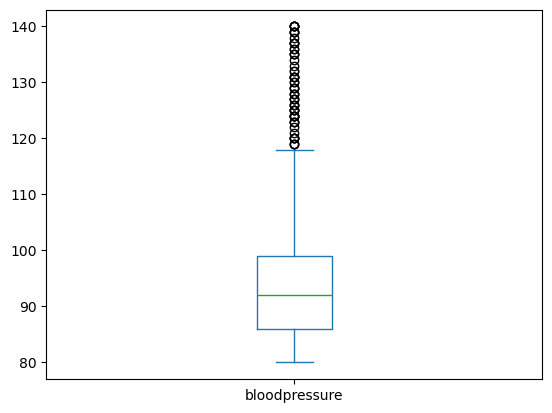

In [26]:
df['bloodpressure'].plot(kind='box')

## 4. Children
**conclusion**
- this column is positively skewed
- Most individuals have 0–2 children

In [28]:
df['children'].describe()

count    1340.000000
mean        1.093284
std         1.205334
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

In [29]:
df['children'].isnull().sum()

np.int64(0)

<Axes: ylabel='Density'>

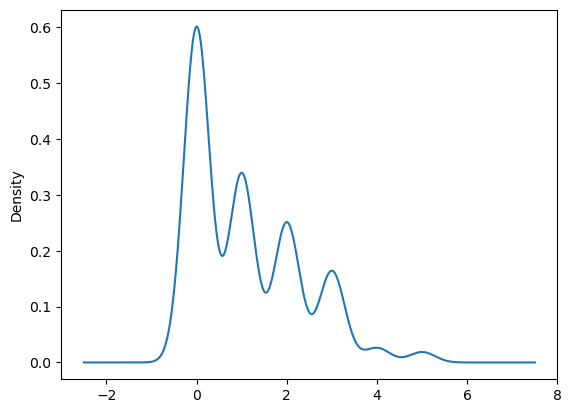

In [30]:
df['children'].plot(kind='kde')

In [31]:
df['children'].skew()

np.float64(0.9402991133470963)

<Axes: ylabel='Frequency'>

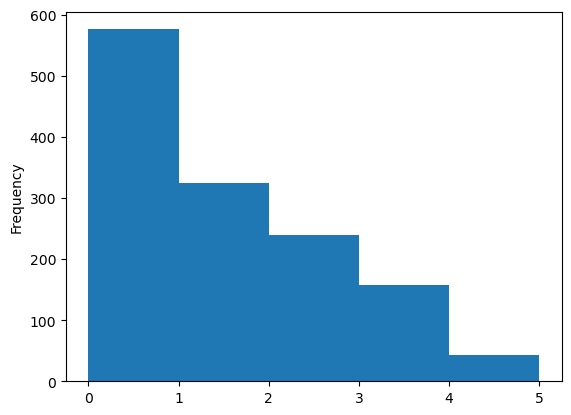

In [32]:
df['children'].plot(kind='hist',bins=5)

<Axes: >

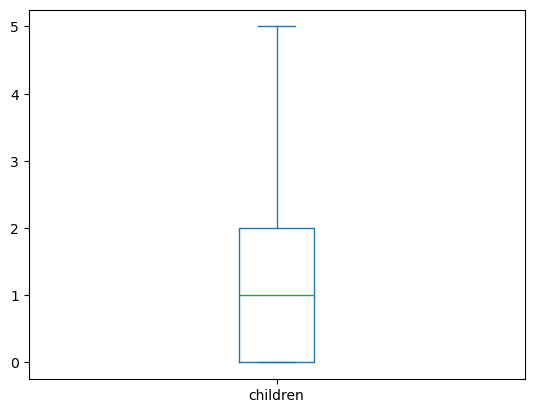

In [33]:
df['children'].plot(kind='box')

## 5. Claim
**conclusions**
- this column is positively skewed
- The claim amount is positively skewed with several high-value outliers. These likely represent individuals with expensive medical treatments rather than data errors.


In [34]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

<Axes: ylabel='Density'>

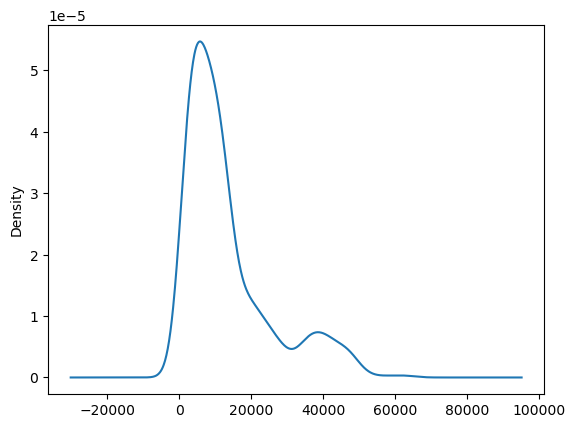

In [35]:
df['claim'].plot(kind='kde')

<Axes: ylabel='Frequency'>

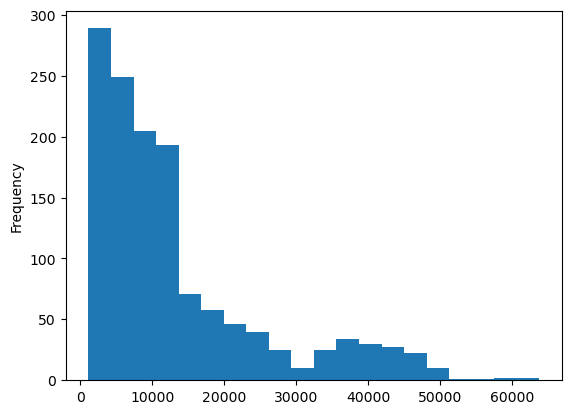

In [36]:
df['claim'].plot(kind='hist',bins=20)

In [37]:
df['claim'].skew()

np.float64(1.5167468509489237)

In [38]:
df['claim'].isnull().sum()

np.int64(0)

<Axes: >

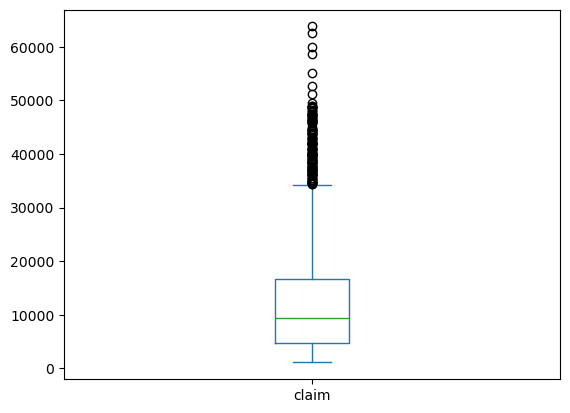

In [39]:
df['claim'].plot(kind='box')

## @ Categorical columns

## 1.Gender
**conclusions**
- The dataset contains an almost equal proportion of males and females.

In [41]:
df['gender'].value_counts()

gender
male      678
female    662
Name: count, dtype: int64

In [42]:
df['gender'].isnull().sum()

np.int64(0)

<Axes: xlabel='gender'>

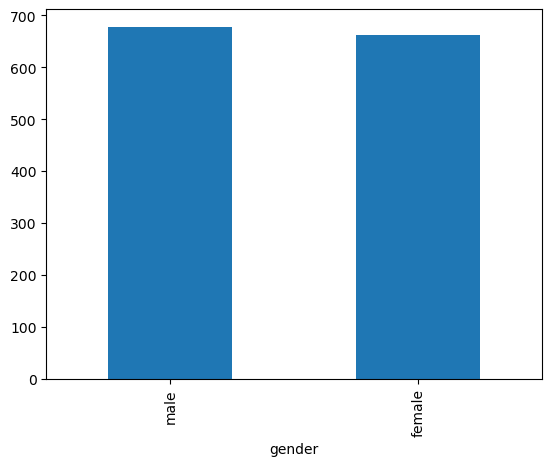

In [43]:
df['gender'].value_counts().plot(kind='bar')

<Axes: >

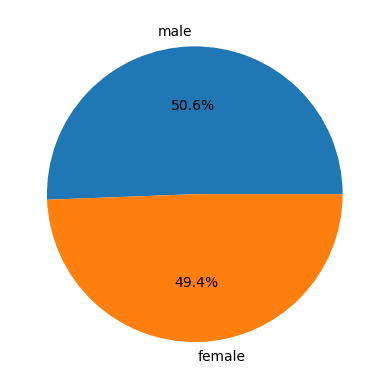

In [44]:
df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## 2.Diabetic
**conclusions**
- The dataset contains an almost equal proportion of diabetic and non-diabetic individuals.

In [45]:
df['diabetic'].value_counts()

diabetic
No     698
Yes    642
Name: count, dtype: int64

In [46]:
df['diabetic'].isnull().sum()

np.int64(0)

<Axes: xlabel='diabetic'>

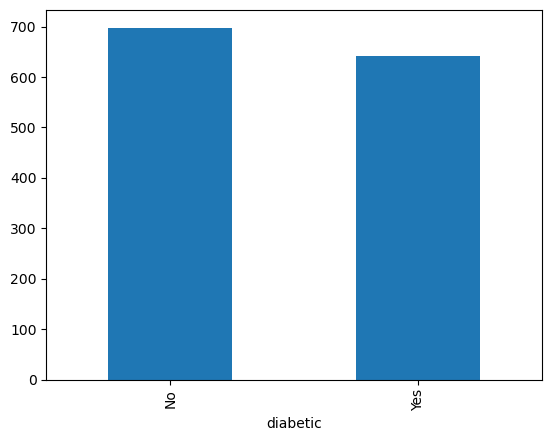

In [47]:
df['diabetic'].value_counts().plot(kind='bar')

<Axes: >

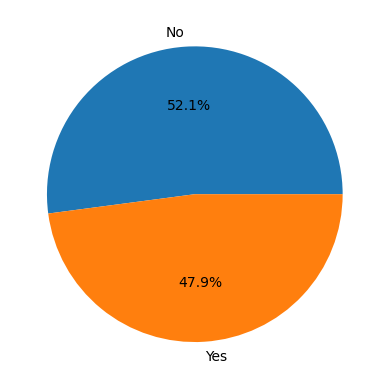

In [48]:
df['diabetic'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## 3. Smoker
**conclusion**
- The majority of individuals in the dataset are non-smokers.

In [49]:
df['smoker'].value_counts()

smoker
No     1066
Yes     274
Name: count, dtype: int64

In [50]:
df['smoker'].isnull().sum()

np.int64(0)

<Axes: xlabel='smoker'>

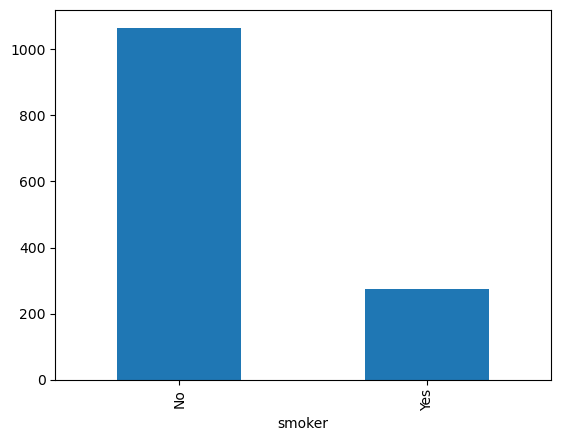

In [51]:
df['smoker'].value_counts().plot(kind='bar')

<Axes: >

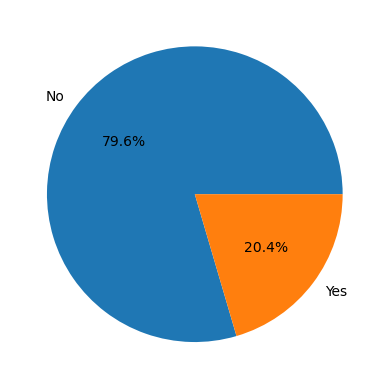

In [52]:
df['smoker'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## 4.Region
**conclusions**
- The Southeast region contains the highest proportion of individuals (33.1%).
- The Northeast region has the lowest proportion of individuals (17.3%).
- The Northwest and Southwest regions have similar representations in the dataset.
- Overall, the regional distribution is moderately imbalanced, with the Southeast region being the most represented.

In [53]:
df['region'].value_counts()

region
southeast    446
northwest    349
southwest    314
northeast    231
Name: count, dtype: int64

In [54]:
df['region'].isnull().sum()

np.int64(0)

<Axes: xlabel='region'>

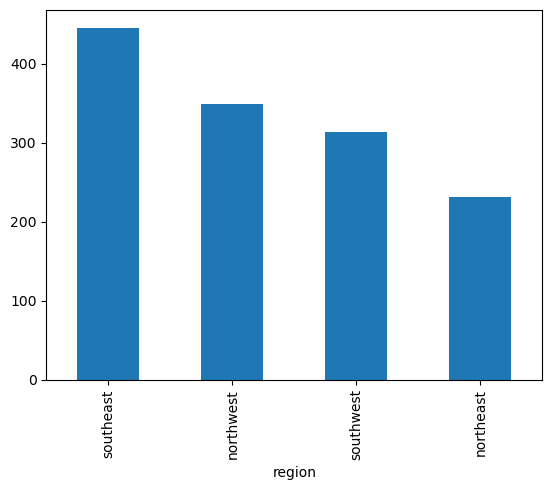

In [55]:
df['region'].value_counts().plot(kind='bar')

<Axes: >

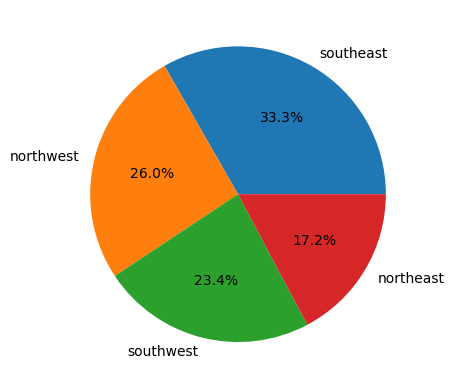

In [56]:
df['region'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# Bivariate Analysis

## Claim vs Gender
### **conclusion**
- The avg value of claim for males is greater than the avg value of claim for females.
- There are outliers for both male and female 

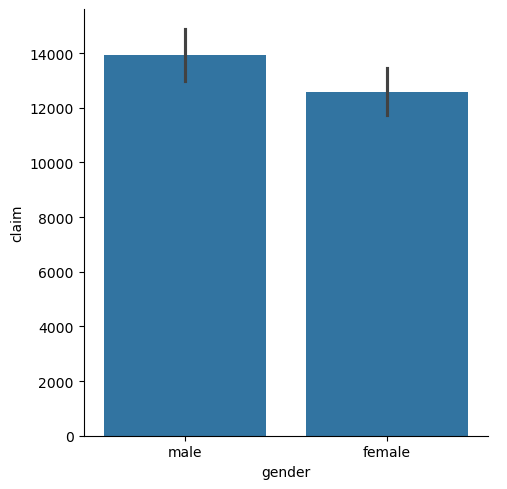

In [58]:
sns.catplot(data=df,kind='bar',x='gender',y='claim')

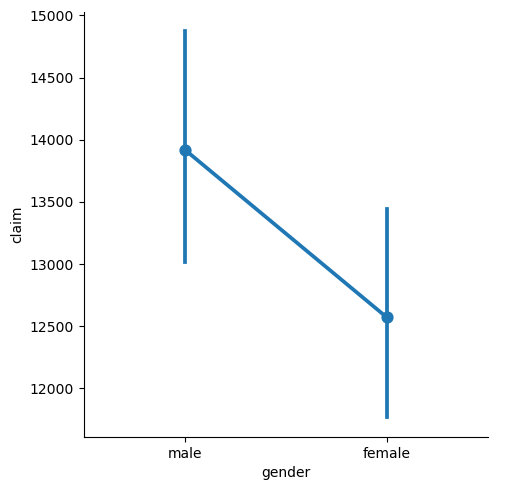

In [59]:
sns.catplot(data=df,kind='point',x='gender',y='claim')

<Axes: xlabel='gender', ylabel='claim'>

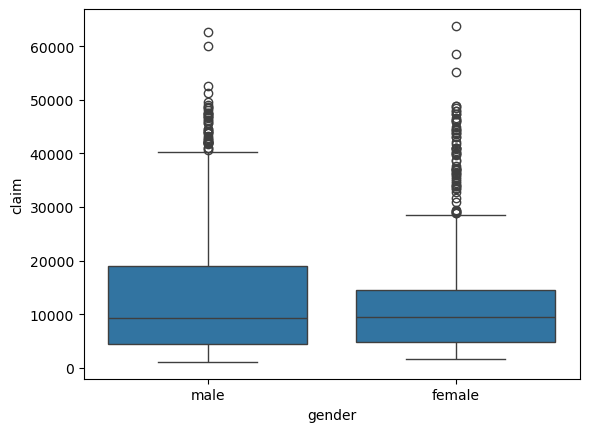

In [60]:
sns.boxplot(data=df, x='gender', y='claim')

## Heatmap Correlation 
### **conclusion**
- There is moderate postive correlation between claim and bloodpressure
- Positive correlation between claim and bmi
- Positive correlation between bmi and bloodpressure
- Most other variables exhibit weak correlations.

In [61]:
df_corr = df.drop(columns=['index','PatientID'])

In [62]:
corr = df_corr.corr(numeric_only=True)

<Axes: >

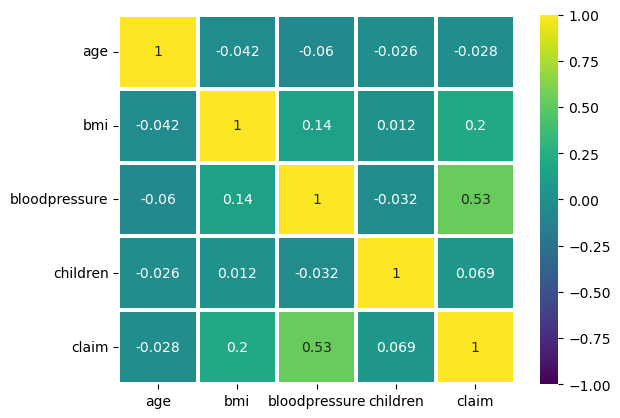

In [63]:
sns.heatmap(corr,linewidths=1.5,vmin=-1,vmax=1,center=0,cmap='viridis',annot=True)

## Claim vs bloodpressure
### **conclusions**
- most of the individuals with bloodpressure 80-100 have claim amount less than 12000
- individuals with bloodpressure greater than 111 have higher claim amount (<26000)

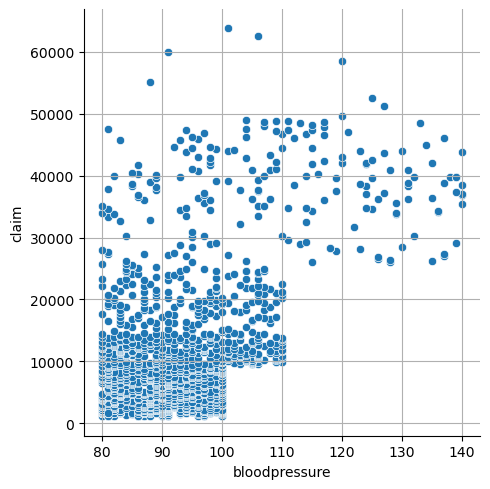

In [64]:
sns.relplot(df,kind='scatter',x='bloodpressure',y='claim')
plt.grid()

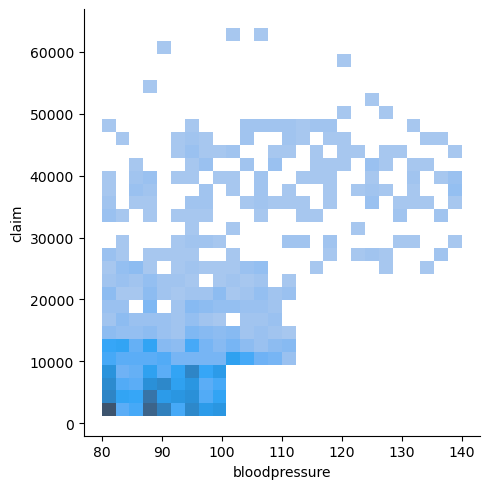

In [65]:
sns.displot(df,kind='hist',x='bloodpressure',y='claim')

## Claim vs BMI
### **conclusion**
- Most claims are concentrated among individuals with bmi between 25 to  35.
- individuals with higher bmi tend to have higher claim amounts

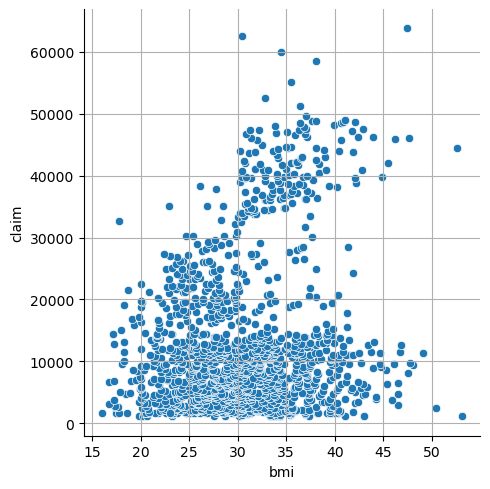

In [66]:
sns.relplot(df,kind='scatter',x='bmi',y='claim')
plt.grid()

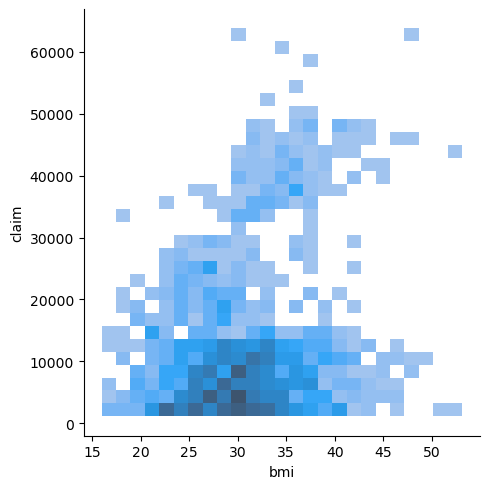

In [67]:
sns.displot(df,kind='hist',x='bmi',y='claim')

## Claim vs Diabetic
### **conclusions**
- There is no as such difference between mean claim amount for diabetic and non-diabetic individuals.
- There are high-value outliers in both diabetic and non-diabetic


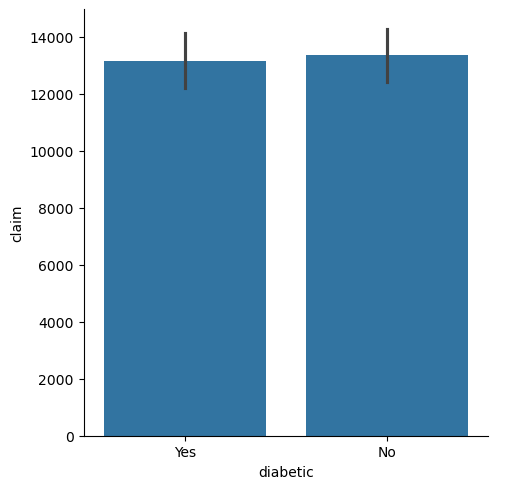

In [69]:
sns.catplot(df,kind='bar',x='diabetic',y='claim')

<Axes: xlabel='diabetic', ylabel='claim'>

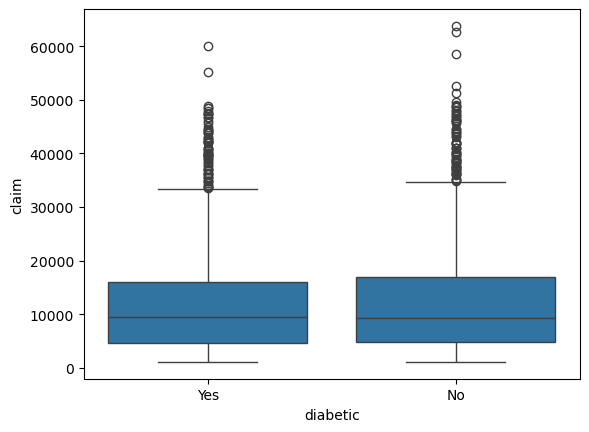

In [70]:
sns.boxplot(data=df,x='diabetic',y='claim')

## Claim vs Smoker
### **conclusion**
- The mean claim amount of smokers is greater than non-smokers.
- This shows that smoker customers get higher claim than non smokers. 


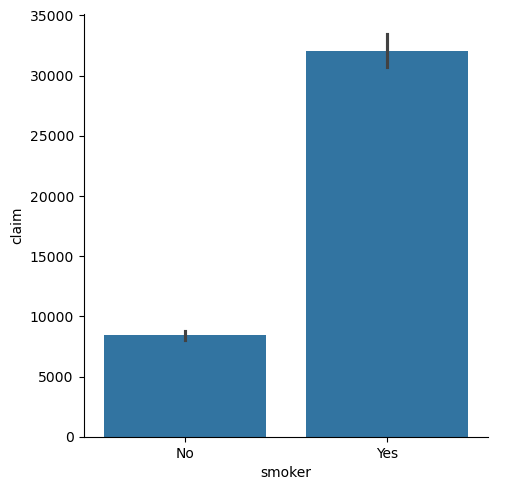

In [71]:
sns.catplot(data=df,kind='bar',x='smoker',y='claim')

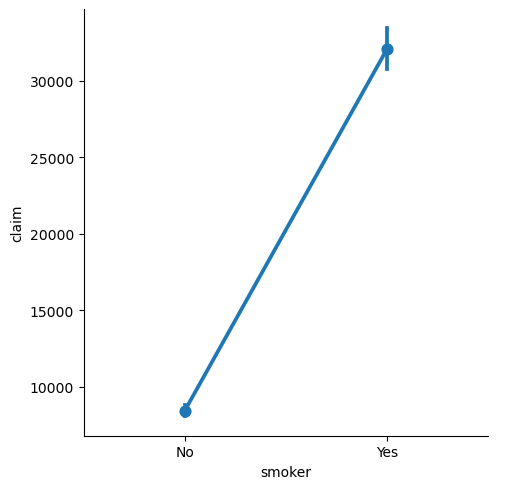

In [72]:
sns.catplot(data=df,kind='point',x='smoker',y='claim')

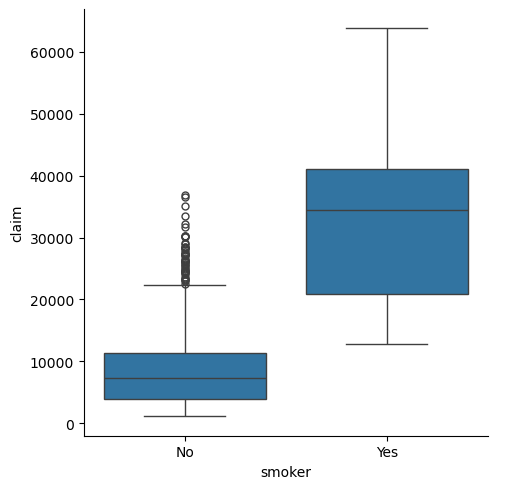

In [73]:
sns.catplot(data=df,kind='box',x='smoker',y='claim')

## Claim vs Region
### **conclusion**
- individuals in the northeast region have highest mean claim
- There are several high-value outliers in every category.

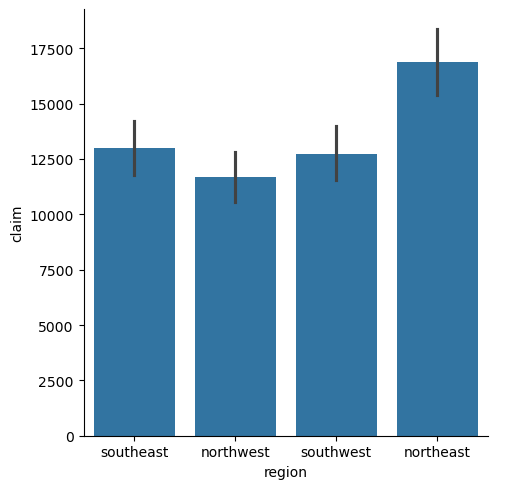

In [74]:
sns.catplot(data=df,kind='bar',x='region',y='claim')

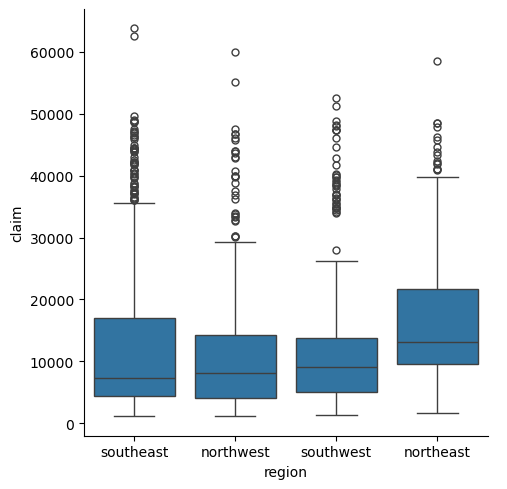

In [75]:
sns.catplot(data=df,kind='box',x='region',y='claim')

## Claim vs Children
### **conclusion**
- The median claim amount is fairly similar across all groups of children.
- Customers with 2–4 children show greater variability in claim amounts.
- There are several high-value outliers in every category.
- Overall, the number of children does not appear to have a strong impact on insurance claim amounts.

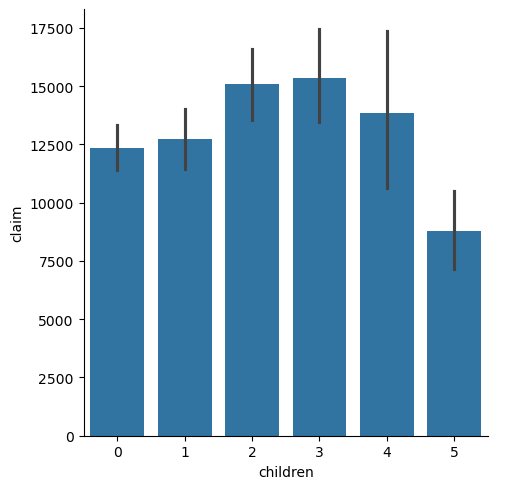

In [76]:
sns.catplot(data=df,kind='bar',x='children',y='claim')

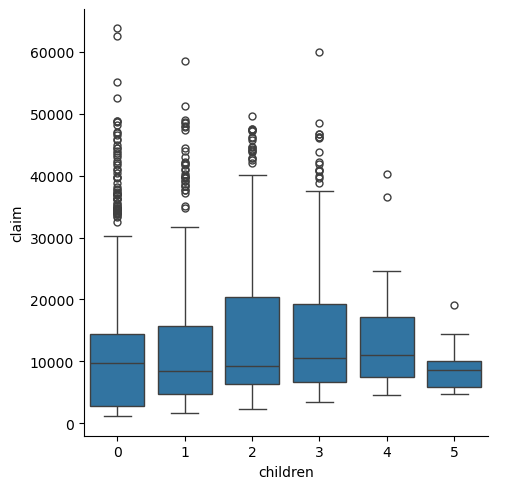

In [77]:
sns.catplot(data=df,kind='box',x='children',y='claim')

## Region Vs Smoker
### **conclusion**
- Southeast region has the highest number of smokers
- Northwest and southwest region have the lowest number of smokers
- Majority of the individuals in every region is a non smoker


<Axes: xlabel='region', ylabel='smoker'>

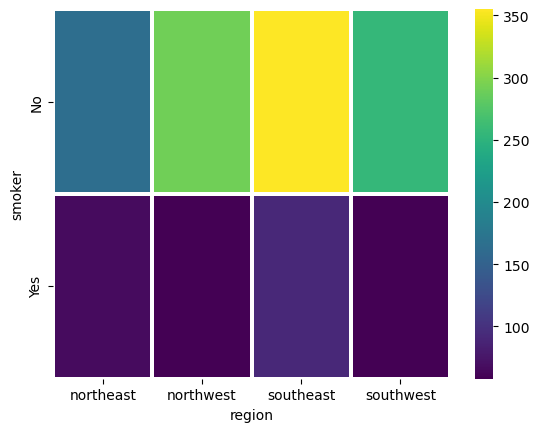

In [78]:
sns.heatmap(pd.crosstab(df['smoker'], df['region']),linewidths=1.5,cmap='viridis')

# Multi-variate Analysis

## Claim vs smoker for male & female
### **conclusion**
- Smokers have significantly higher insurance claims than non-smokers.
- Male smoker have slightly higher median claim than females.
- Claim amounts among smokers show greater variability.
- Few non smokers have hight claim amount

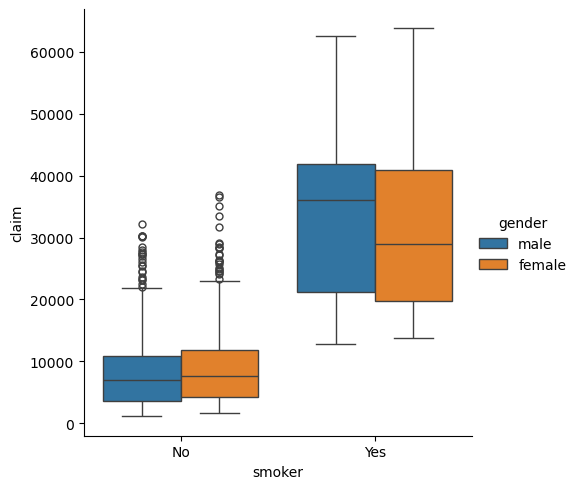

In [80]:
sns.catplot(data=df,kind='box',x='smoker',y='claim',hue='gender')

# Key Insights

- **Smoking status has the greatest impact on insurance claim amounts.**
    - *Smokers have significantly higher mean and median claim amounts than non-smokers, with greater variability in claims.*
- **Blood pressure is moderately positively correlated with insurance claim amounts.**
    - *Individuals with higher blood pressure generally tend to have higher insurance claims.*
- **BMI has a weak positive relationship with insurance claim amounts.**
    - *Higher BMI is associated with slightly higher claim amounts, although the relationship is not very strong.*
- **Gender and diabetic status have little influence on claim amounts.**
    - *The average claim amounts for males and females, as well as diabetic and non-diabetic individuals, do not differ substantially.*
- **The number of children has minimal impact on insurance claims.**
    - *Median claim amounts are similar across different numbers of children, despite some variability and outliers.*
- **Regional differences exist in the dataset.**
    - *The Southeast region has the highest number of smokers, while the Northeast region has the highest average claim amount.*
- **The dataset contains several high-value claim outliers.**
    - *These are present across multiple categories and are especially noticeable among smokers.*